# STARTER

In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# MANIFESTO

In [5]:
from scripts.utils.logger import logger

In [6]:
logger_params = {
    "main_folder": "/home/think/Desktop/strats",
    "experiment_name": "LSTM_univariate_strats_v2",
    "date": "2025-10-15",
    "iteration": 1,
    "description": (
        "Se entrenara una LSTM con lorenz63 canonico caotico"
        "en modo univariable para las 5 strategies,"
        "el proposito es que podamos dejar una plantilla"
    )
}

In [7]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/strats/LSTM_univariate_strats_v2_2025-10-15_iter1
Manifesto written to: /home/think/Desktop/strats/LSTM_univariate_strats_v2_2025-10-15_iter1/manifesto.txt


# DATA

In [25]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()['x']

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 70% for training
val_size = int(0.20 * n_samples)     # 10% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.reshape(-1, 1))
val_scaled = scaler.transform(val_data.reshape(-1, 1))
test_scaled = scaler.transform(test_data.reshape(-1, 1))

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

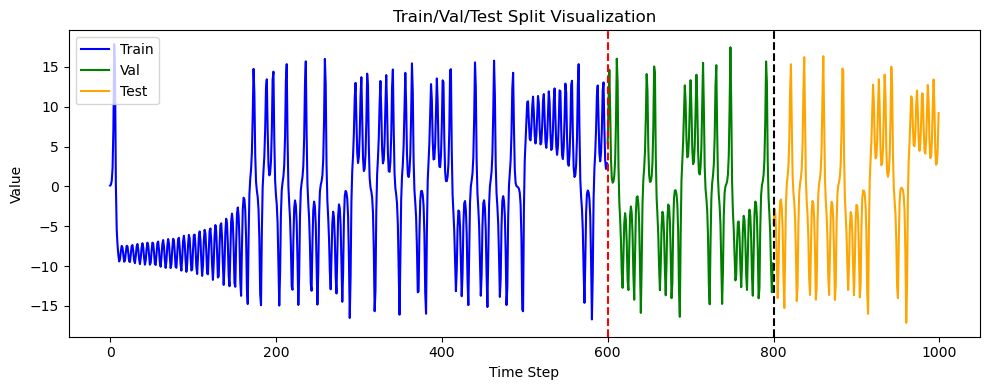

In [26]:
# Define x-axis ranges based on the lengths
train_end = len(train_data)
val_end = len(train_data) + len(val_data)
x_train = np.arange(train_end)
x_val =np.arange(train_end, train_end + len(val_data))
x_test = np.arange(val_end, val_end + len(test_data))
# Plot
plt.figure(figsize=(10, 4))
plt.plot(x_train, train_data, label='Train', color='blue')
plt.plot(x_val, val_data, label='Val', color='green')
plt.plot(x_test, test_data, label='Test', color='orange')

# Optional vertical line to indicate the split
plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
plt.legend()
plt.title("Train/Val/Test Split Visualization")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# RECURSIVE-UNIVARIATE

In [27]:
# univariate data preparation
from numpy import array
#split a univariate sequence into samples
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i +n_steps
        if end_ix > len(sequence) - 1:
            break
        #gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [24]:
# choose a number of time steps
n_steps = 1
# split into samples
X, y = split_sequence(train_scaled.flatten(), n_steps)  
# reshape from [samples, timesteps] into [samples, timestepsm features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [32]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Conv1D
from keras.layers import MaxPooling1D

def recursive_cnn(n_steps, n_features):
    # define model
    model = Sequential()
    model.add(Conv1D(64, 1, activation = 'relu', input_shape=(n_steps, n_features)))
    model.add(MaxPooling1D())
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model



# # define model
# model = Sequential()
# model.add(Conv1D(64, 2, activation = 'relu', input_shape=(n_steps, n_features)))
# model.add(MaxPooling1D())
# model.add(Flatten())
# model.add(Dense(50, activation='relu'))
# model.add(Dense(1))
# model.compile(optimizer='adam', loss='mse')

In [17]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense

def vanilla_lstm(n_steps, n_features, units=100):
    """Return a compiled vanilla LSTM model."""
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps, n_features)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [33]:
model_recursive_cnn = recursive_cnn(n_steps, n_features)
model_recursive_cnn.fit(X, y, epochs=100, verbose=0)

ValueError: Exception encountered when calling MaxPooling1D.call().

[1mNegative dimension size caused by subtracting 2 from 1 for '{{node sequential_2_1/max_pooling1d_2_1/MaxPool1d}} = MaxPool[T=DT_FLOAT, data_format="NHWC", explicit_paddings=[], ksize=[1, 1, 2, 1], padding="VALID", strides=[1, 1, 2, 1]](sequential_2_1/max_pooling1d_2_1/MaxPool1d/ExpandDims)' with input shapes: [?,1,1,64].[0m

Arguments received by MaxPooling1D.call():
  • inputs=tf.Tensor(shape=(None, 1, 64), dtype=float32)

In [11]:
model_recursive = vanilla_lstm(n_steps, n_features)
model_recursive.fit(X, y, epochs=100, verbose=0)

2025-10-14 19:58:20.637865: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
import numpy as np

def recursive_OS_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    uno = starter_sample.reshape((1, n_steps, n_features)) 
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(horizon):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv[0, 0])
        else:
            predictions.append(yhat_scaled[0, 0])

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [19]:
starter_sample = train_scaled[-1].reshape((1, n_steps, n_features)) 
horizon_recursive = 20
predictions_recursive = recursive_OS_predictions(starter_sample, 
                                                 horizon_recursive, 
                                                 model_recursive, scaler = None)

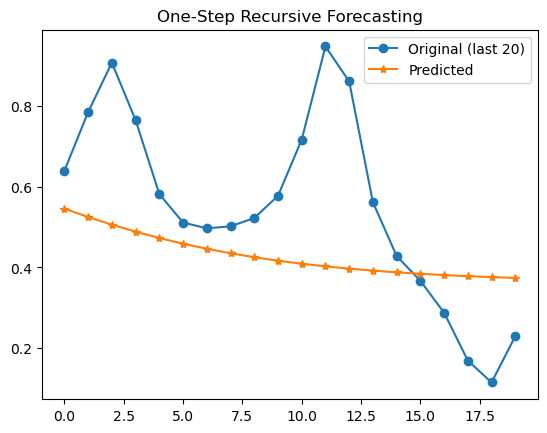

In [20]:
# Plot
plt.plot(val_scaled[:horizon_recursive], label='Original (last 20)', marker='o')
plt.plot(predictions_recursive, label='Predicted', marker='*')
plt.legend()
plt.title('One-Step Recursive Forecasting')
plt.show()

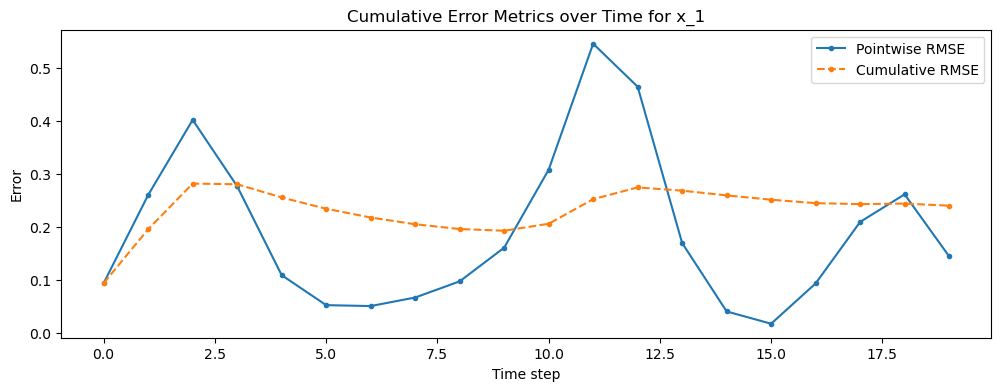

In [28]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 1

for i in range(n_features):

    y_pred = predictions_recursive
    y_true = val_scaled[:horizon_recursive]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# DIRECT-UNIVARIATE

In [30]:
# univariate data preparation
from numpy import array
#split a univariate sequence into samples
def split_sequence_direct(sequence, n_steps, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i +n_steps 
        # print(end_ix)
        if end_ix > len(sequence) - 1 - skip:
            break
        #gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix+skip]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [36]:
# choose a number of time steps
n_steps = 1
horizon_direct = 20
datasets = {}
for i in range(horizon_direct):
    X, y = split_sequence_direct(train_scaled, n_steps, i)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    datasets[i] = (X, y)  # store as tuple

In [32]:
models_direct = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps, n_features)
    model.fit(X, y, epochs=100, verbose=0)
    models_direct[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
starter_sample = train_scaled[-1].reshape((1, n_steps, n_features)) 
predictions_direct = []

for i in models_direct:  # skip = number of horizons / models
    model = models_direct[i]
    yhat = model.predict(starter_sample, verbose=0)
    predictions_direct.append(yhat[0, 0])  # flatten the output

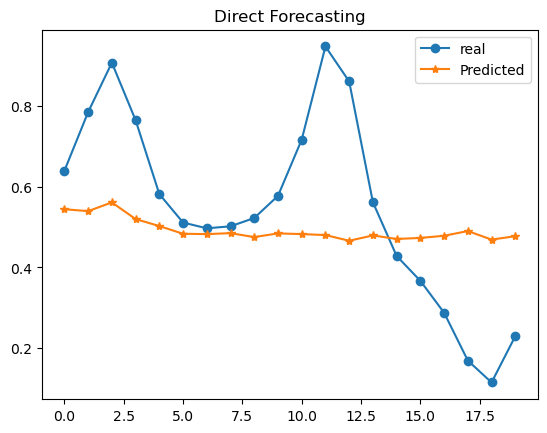

In [37]:
# Plot
plt.plot(val_scaled[:horizon_direct], marker='o', label = 'real')
plt.plot(predictions_direct, label='Predicted', marker='*')
plt.legend()
plt.title('Direct Forecasting')
plt.show()

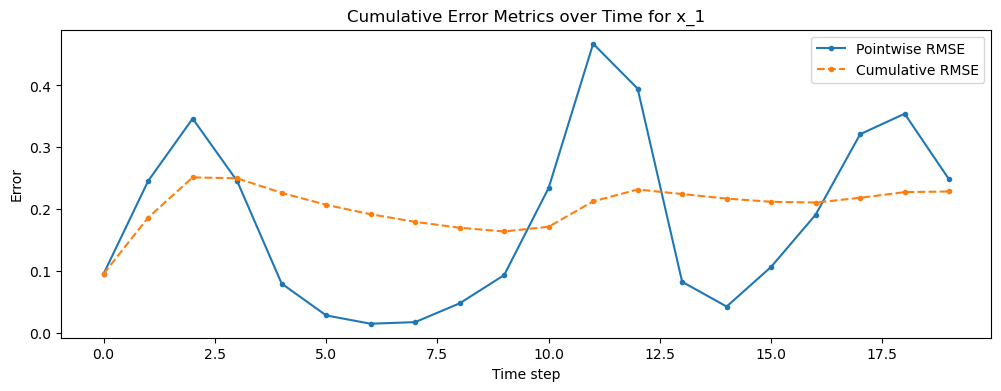

In [38]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 1

for i in range(n_features):

    y_pred = predictions_direct
    y_true = val_scaled[:horizon_recursive]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# DIREC-UNIVARIATE
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$. Se entrena un modelo para predecir $B$ pasos, y la predicción del bloque se reutiliza como entrada del siguiente bloque hasta alcanzar $H$.  

In [39]:
# univariate data preparation
from numpy import array
#  split a univariate sequence into samples
def split_sequence_direc(sequence, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # print(i,end_ix)
        # print(end_ix,out_end_ix)
        # check if we are beyond the sequence
        if out_end_ix > len(sequence)- skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[skip+end_ix:skip + out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [40]:
# choose a number of time steps
n_steps_in = 3
n_steps_out = 3
skip=0
# split into samples
X, y = split_sequence_direc(train_scaled, n_steps_in, n_steps_out, skip)   

In [41]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [42]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_direct(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [43]:
model_direc = vanilla_lstm_direct(n_steps_in, n_steps_out,n_features)
model_direc.fit(X, y, epochs=800, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def direc_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    n_steps_in = len(starter_sample)
    uno = starter_sample.reshape((1, n_steps_in, n_features)) 
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(0, horizon, len(starter_sample)):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv)
        else:
            predictions.append(yhat_scaled)

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [45]:
starter_sample = train_scaled[-3:] #.reshape((1, n_steps_in, n_features)) 
horizon_direc = 21
predictions_direc = direc_predictions(starter_sample, horizon_direc, model_direc, scaler = None)

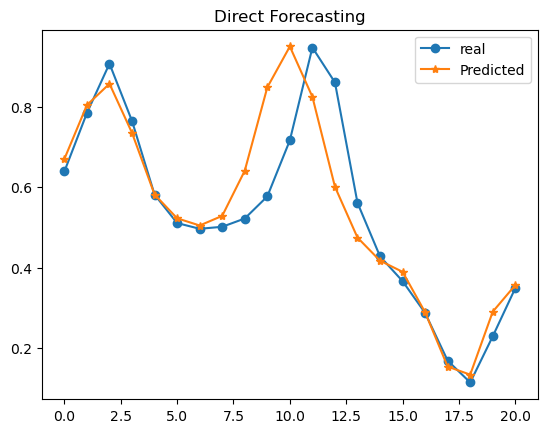

In [ ]:
# Plot
plt.plot(val_scaled[:horizon_direc], marker='o', label = 'real')
plt.plot(predictions_direc.flatten(), label='Predicted', marker='*')
plt.legend()
plt.title('Direct Forecasting')
plt.show()

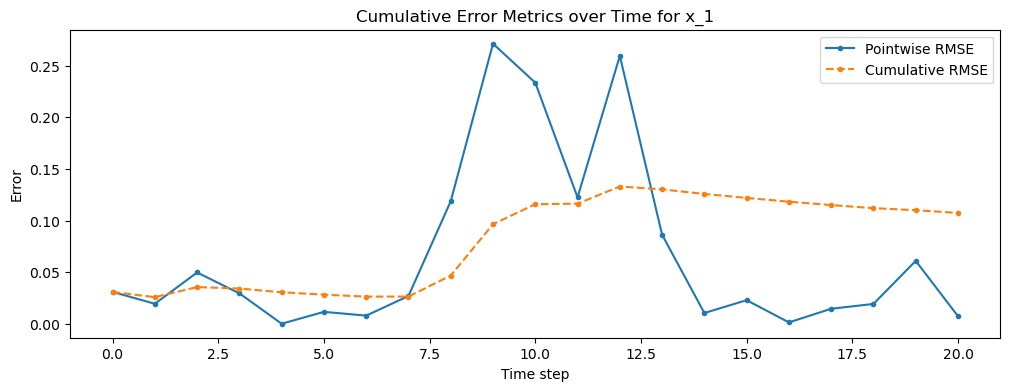

In [48]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 1

for i in range(n_features):

    y_pred = predictions_direc.flatten()
    y_true = val_scaled[:horizon_direc]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# MIMO-UNIVARIATE
Entrenar un único modelo capaz de predecir directamente los $H$ pasos en una sola iteración. 

In [49]:
# split a univariate sequence into samples
def split_sequence(sequence, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [50]:
# choose a number of time steps
n_steps_in = 20
n_steps_out = 20
# split into samples
X, y = split_sequence(train_scaled, n_steps_in, n_steps_out)   

In [51]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [52]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_direct(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [53]:
model_MIMO = vanilla_lstm_direct(n_steps_in, n_steps_out,n_features)
model_MIMO.fit(X, y, epochs=800, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
starter_sample = train_scaled[-20:].reshape((1, n_steps_in, n_features)) 
horizon_MIMO = 20
predictions_MIMO = model_MIMO.predict(starter_sample, verbose = 0)

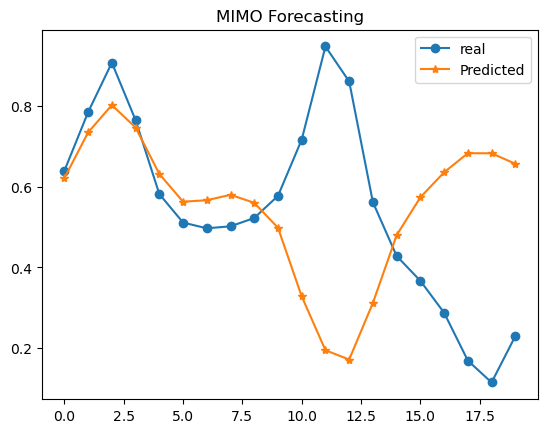

In [55]:
# Plot
plt.plot(val_scaled[:horizon_MIMO], marker='o', label = 'real')
plt.plot(predictions_MIMO.flatten(), label='Predicted', marker='*')
plt.legend()
plt.title('MIMO Forecasting')
plt.show()

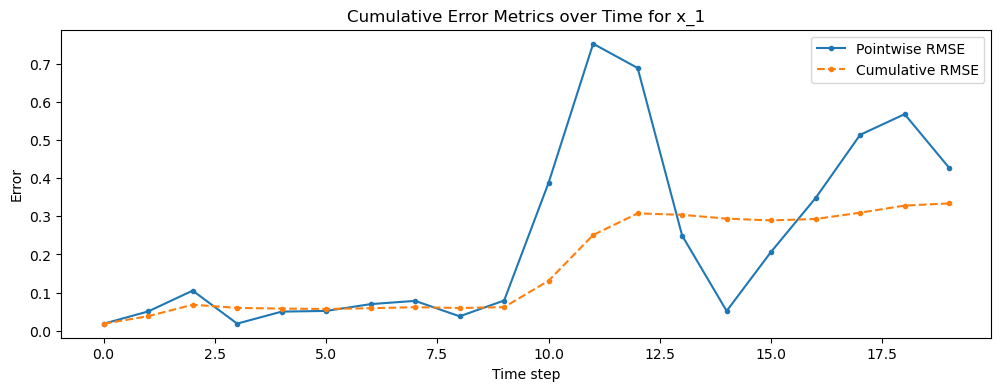

In [56]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 1

for i in range(n_features):

    y_pred = predictions_MIMO.flatten()
    y_true = val_scaled[:horizon_MIMO]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()

# DIRMO-UNIVARIATE
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$, y entrenar $N$ modelos, cada uno encargado de predecir $B$ pasos consecutivos. 

In [57]:
# univariate data preparation
from numpy import array
#  split a univariate sequence into samples
def split_sequence_dirMO(sequence, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # print(i,end_ix)
        # print(end_ix,out_end_ix)
        # check if we are beyond the sequence
        if out_end_ix > len(sequence)- skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[skip+end_ix:skip + out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [58]:
# choose a number of time steps
n_steps_in = 5
n_steps_out = 5
horizon_DIRMO = 20
datasets = {}
for i in range(0,horizon_DIRMO, n_steps_out):
    X, y = split_sequence_dirMO(train_scaled, n_steps_in, n_steps_out, i)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    datasets[i] = (X, y)  # store as tuple

In [59]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_dirMO(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [60]:
models_DIRMO = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm_dirMO(n_steps_in, n_steps_out, n_features, units = 100)
    model.fit(X, y, epochs=500, verbose=0)
    models_DIRMO[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np
# Initialize input
starter_sample = train_scaled[-5:]
n_steps_in = len(starter_sample)
uno = starter_sample.reshape((1, n_steps_in, n_features)) 
# List to store predictions
predictions_DIRMO = []
# Loop to predict one step at a time
for i in models_DIRMO:
    model = models_DIRMO[i]
    yhat_scaled = model.predict(uno, verbose=0) 
    predictions_DIRMO.append(yhat_scaled)
# Convert predictions to numpy array
predictions_DIRMO = np.array(predictions_DIRMO)

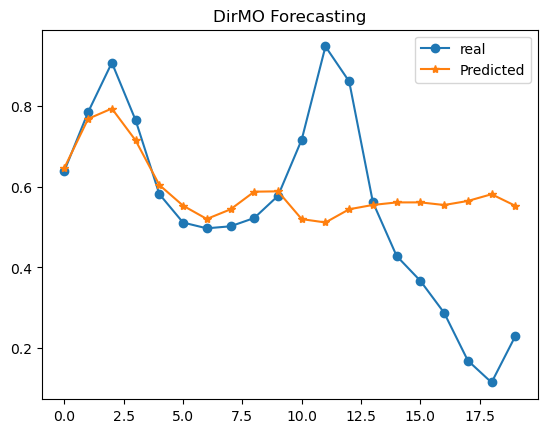

In [64]:
# Plot
plt.plot(val_scaled[:horizon_DIRMO], marker='o', label = 'real')
plt.plot(predictions_DIRMO.flatten(), label='Predicted', marker='*')
plt.legend()
plt.title('DirMO Forecasting')
plt.show()

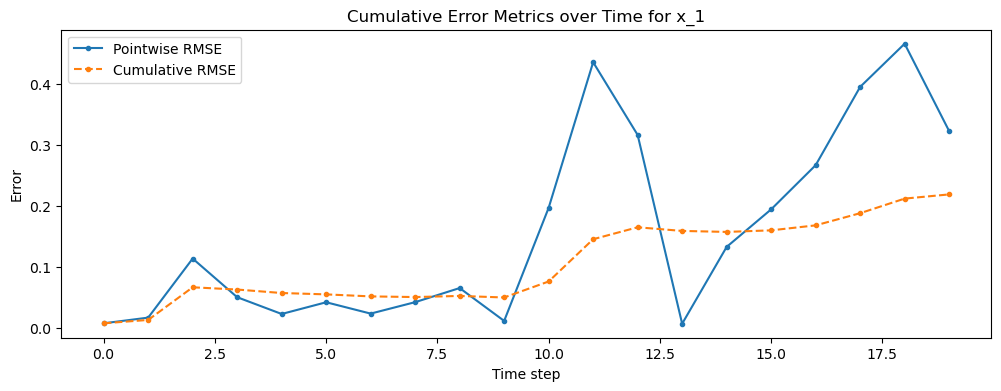

In [65]:
import numpy as np
import matplotlib.pyplot as plt

n_features = 1

for i in range(n_features):

    y_pred = predictions_DIRMO.flatten()
    y_true = val_scaled[:horizon_DIRMO]

    # Pointwise errors
    error = y_pred - y_true
    abs_error = np.abs(error)
    
    # Pointwise metrics
    mse_pointwise = error**2
    rmse_pointwise = np.sqrt(mse_pointwise)
    # Avoid divide by zero for percentage errors
    mape_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true)) * 100
    maspe_pointwise = np.abs(error / np.where(y_true==0, 1e-8, y_true) - 1)
    
    # Cumulative metrics
    cum_abs_error = np.cumsum(abs_error)
    cum_mse = np.cumsum(mse_pointwise) / (np.arange(len(error)) + 1)
    cum_rmse = np.sqrt(cum_mse)
    cum_mape = np.cumsum(mape_pointwise) / (np.arange(len(error)) + 1)
    cum_maspe = np.cumsum(maspe_pointwise) / (np.arange(len(error)) + 1)
    

    plt.figure(figsize=(12, 4))

    # plt.plot(abs_error, linestyle='-', marker='.', label='Abs Pointwise Error')
    # plt.plot(cum_abs_error, linestyle='--', marker='.', label='Abs Cumulative Error')

    plt.plot(rmse_pointwise, marker='.', linestyle='-', label='Pointwise RMSE')
    plt.plot(cum_rmse, linestyle ='--' , marker = '.',label='Cumulative RMSE')
    
    # plt.plot(mape_pointwise, marker='.', linestyle='--', label='Pointwise MAPE')
    # plt.plot(cum_mape, label='Cumulative MAPE')

    # plt.plot(maspe_pointwise, marker='.', linestyle=':', label='Pointwise MASPE')
    # plt.plot(cum_maspe, linestyle ='--',marker = '.',label='Cumulative MASPE')

    plt.title(f'Cumulative Error Metrics over Time for x_{i+1}')
    plt.xlabel('Time step')
    plt.ylabel('Error')
    plt.legend()
    plt.show()